<a href="https://colab.research.google.com/github/felipebatalini/AIHC5020/blob/main/homework5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
--- Problem 1 Challenge Case: ECG DF (Tail) ---
       MLII     V1
5395 -0.275 -0.035
5396 -0.250 -0.015
5397 -0.245 -0.005
5398 -0.245  0.005
5399 -0.250  0.000

--- Problem 1 Challenge Case: Annotations DF (Tail) ---
    annotation_index annotation_text
13              3960               N
14              4283               N
15              4609               N
16              4928               N
17              5241               N


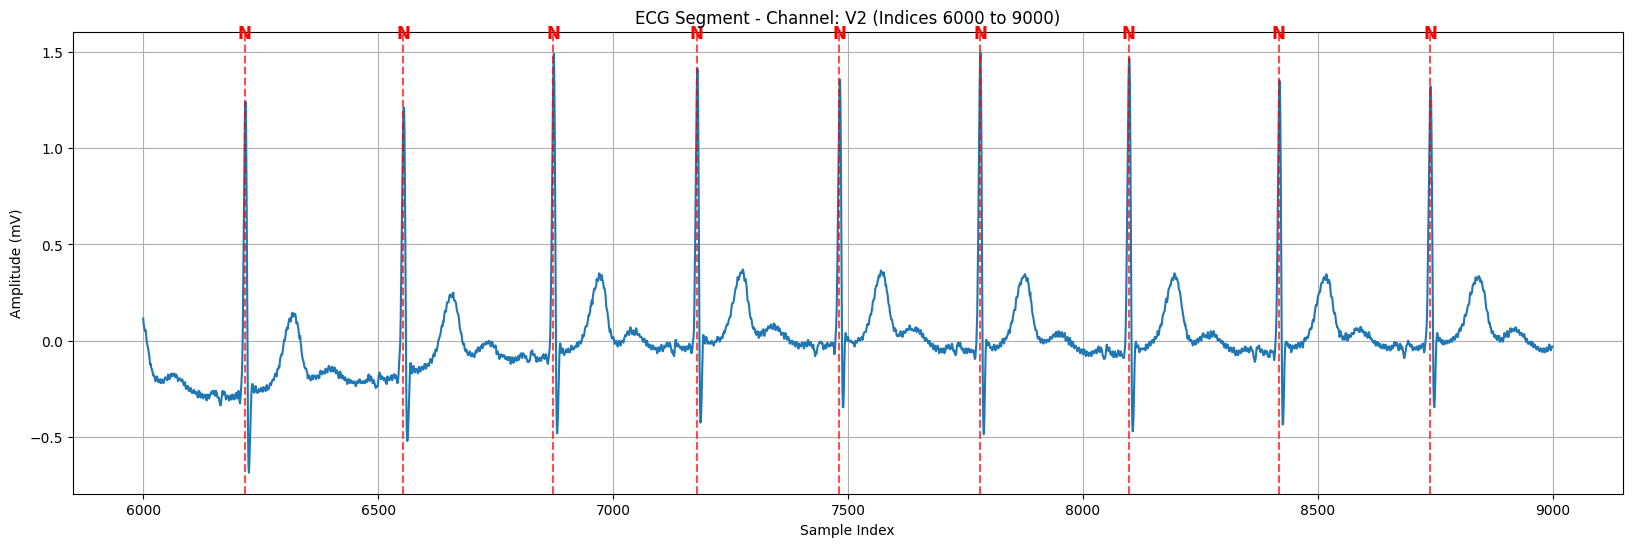


--- Problem 3 Challenge Case: Segment Table (Head) ---
   record_number  segment_index  sample_rate  n_samples channel_name  \
0            102              0          360       1350           V5   
1            102              0          360       1350           V2   
2            102              1          360       1350           V5   
3            102              1          360       1350           V2   
4            102              2          360       1350           V5   

   segment_start_index                                            segment  
0                    0  [-0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0....  
1                    0  [0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.0...  
2                 1350  [-0.41, -0.4, -0.385, -0.37, -0.34, -0.305, -0...  
3                 1350  [-2.465, -2.285, -2.11, -1.905, -1.67, -1.425,...  
4                 2700  [-0.225, -0.23, -0.24, -0.245, -0.255, -0.25, ...  

--- Problem 4 Challenge Case: CT Series Manifest ---
 

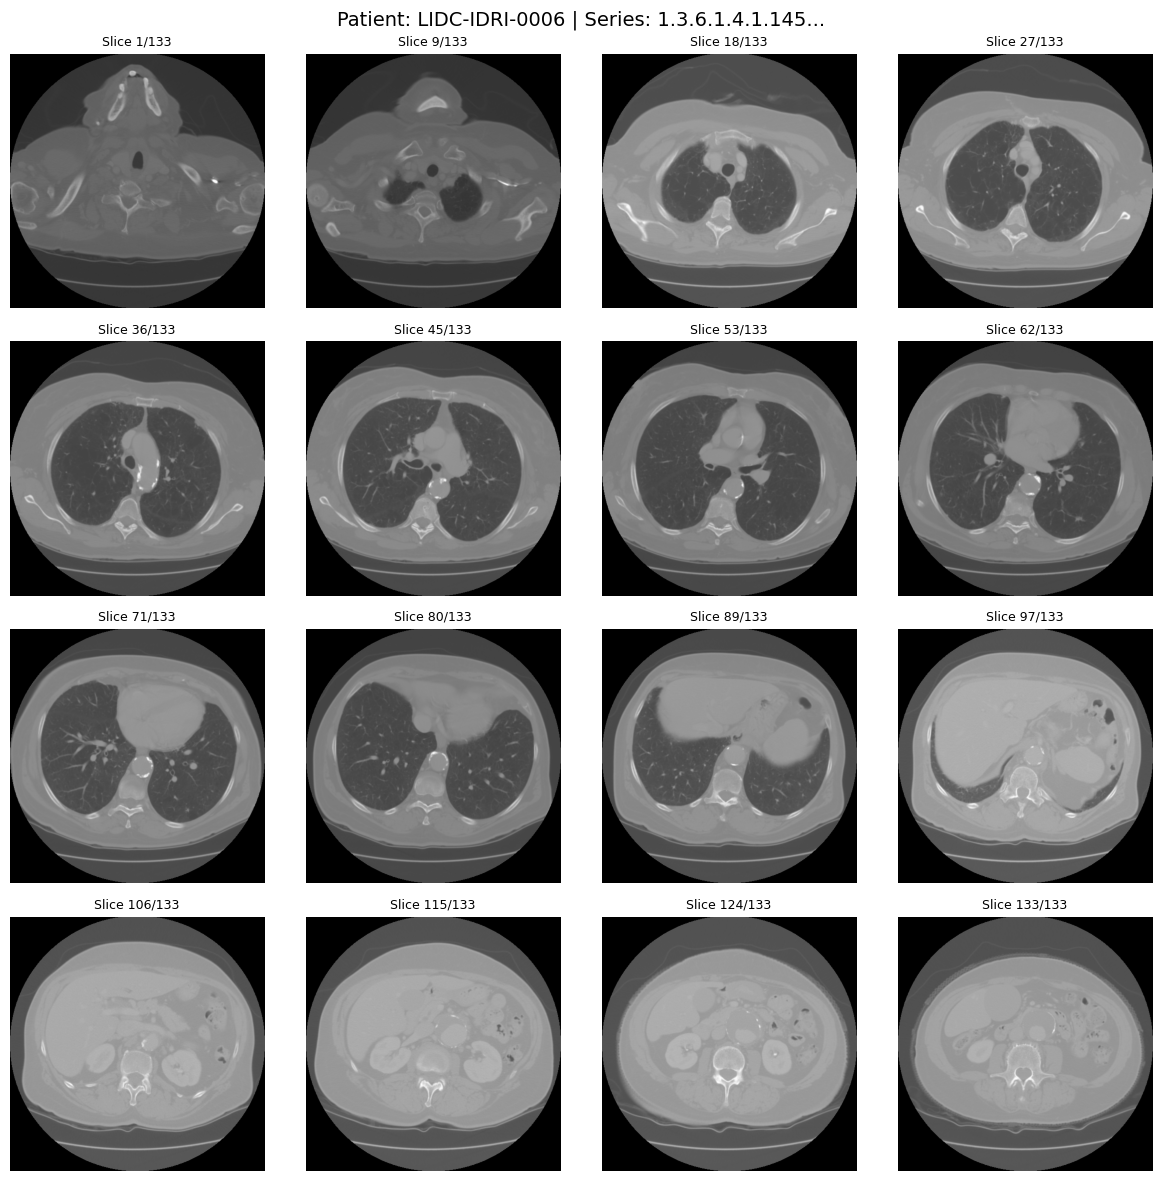

In [6]:
# Install required libraries
!pip install -q wfdb pydicom

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import pydicom

# Safely mount Google Drive if not already mounted
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive', force_remount=False)

# File Paths
WFDB_ROOT = '/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb'
DICOM_ROOT = '/content/drive/MyDrive/AIHC5020/dicom/tcia/LIDC-IDRI'

# ==============================================================================
# Problem 1: Loading and Processing MIT-BIH Data
# ==============================================================================
def load_ecg_data(record_number: int, max_duration: int, wfdb_root: str):
    record_path = os.path.join(wfdb_root, str(record_number))
    ecg_record = wfdb.rdrecord(record_path)
    ecg_ann = wfdb.rdann(record_path, extension='atr')

    sample_rate = ecg_record.fs
    cutoff_sample_index = int(max_duration * sample_rate)

    # Time series DataFrame truncated to cutoff index
    ecg_df = pd.DataFrame(
        data=ecg_record.p_signal[:cutoff_sample_index],
        columns=ecg_record.sig_name
    )

    # Convert lists to NumPy arrays before applying boolean mask
    ann_samples = np.array(ecg_ann.sample)
    ann_symbols = np.array(ecg_ann.symbol)

    ann_mask = ann_samples < cutoff_sample_index

    annotations_df = pd.DataFrame({
        'annotation_index': ann_samples[ann_mask],
        'annotation_text': ann_symbols[ann_mask]
    })

    return ecg_df, annotations_df, sample_rate

# Challenge Case - Problem 1: Record 101, 15 seconds max duration
ecg_df_101, ann_df_101, sr_101 = load_ecg_data(101, 15, WFDB_ROOT)
print("--- Problem 1 Challenge Case: ECG DF (Tail) ---")
print(ecg_df_101.tail())
print("\n--- Problem 1 Challenge Case: Annotations DF (Tail) ---")
print(ann_df_101.tail())


# ==============================================================================
# Problem 2: Visualizing ECG Segments and Annotations
# ==============================================================================
def plot_ecg_segment(ecg_df: pd.DataFrame, annotations_df: pd.DataFrame, channel_name: str, start_index: int, end_index: int):
    segment_df = ecg_df.loc[start_index:end_index - 1]

    filtered_ann = annotations_df[
        (annotations_df['annotation_index'] >= start_index) &
        (annotations_df['annotation_index'] < end_index)
    ]

    plt.figure(figsize=(20, 6))
    plt.plot(segment_df.index, segment_df[channel_name], label=channel_name)

    max_val = segment_df[channel_name].max()
    text_y = max_val + (abs(max_val) * 0.05 if max_val != 0 else 0.1)

    for _, row in filtered_ann.iterrows():
        idx = row['annotation_index']
        text = row['annotation_text']
        plt.axvline(x=idx, color='red', linestyle='--', alpha=0.7)
        plt.text(idx, text_y, text, color='red', fontsize=12, fontweight='bold', ha='center')

    plt.title(f"ECG Segment - Channel: {channel_name} (Indices {start_index} to {end_index})")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude (mV)")
    plt.grid(True)
    plt.show()

# Challenge Case - Problem 2: Record 103, 30s load, Channel V2, start 6000, end 9000
ecg_df_103, ann_df_103, _ = load_ecg_data(103, 30, WFDB_ROOT)
plot_ecg_segment(ecg_df_103, ann_df_103, 'V2', 6000, 9000)


# ==============================================================================
# Problem 3: Segment Table Transformation
# ==============================================================================
def create_segment_table(record_number: int, max_duration: int, wfdb_root: str, segment_duration: int):
    ecg_df, _, sample_rate = load_ecg_data(record_number, max_duration, wfdb_root)

    samples_per_segment = int(segment_duration * sample_rate)
    n_segments = int(np.ceil(len(ecg_df) / samples_per_segment))

    signal_splits = np.array_split(ecg_df.values, n_segments)
    index_splits = np.array_split(ecg_df.index.values, n_segments)

    rows = []
    for seg_idx in range(n_segments):
        seg_signal = signal_splits[seg_idx]
        seg_index = index_splits[seg_idx]

        for col_idx, channel in enumerate(ecg_df.columns):
            rows.append({
                'record_number': record_number,
                'segment_index': seg_idx,
                'sample_rate': sample_rate,
                'n_samples': len(seg_signal),
                'channel_name': channel,
                'segment_start_index': seg_index[0],
                'segment': seg_signal[:, col_idx]
            })

    return pd.DataFrame(rows)

# Challenge Case - Problem 3: Record 102, 30s max duration, 4s segments
segment_tbl_102 = create_segment_table(102, 30, WFDB_ROOT, 4)
print("\n--- Problem 3 Challenge Case: Segment Table (Head) ---")
print(segment_tbl_102.head())


# ==============================================================================
# Problem 4: Creating a DICOM Series Manifest
# ==============================================================================
def create_dicom_manifest(root_dir: str):
    root_path = Path(root_dir)
    manifest_data = []

    for dirpath, _, filenames in os.walk(root_path):
        dcm_files = [f for f in filenames if f.lower().endswith('.dcm')]
        if not dcm_files:
            continue

        sample_file_path = os.path.join(dirpath, dcm_files[0])
        try:
            ds = pydicom.dcmread(sample_file_path, stop_before_pixels=True)
            manifest_data.append({
                'patient_id': ds.get('PatientID', 'N/A'),
                'study_date': ds.get('StudyDate', 'N/A'),
                'modality': ds.get('Modality', 'N/A'),
                'study_description': ds.get('StudyDescription', 'N/A'),
                'series_description': ds.get('SeriesDescription', 'N/A'),
                'n_images': len(dcm_files),
                'study_instance_uid': ds.get('StudyInstanceUID', 'N/A'),
                'series_instance_uid': ds.get('SeriesInstanceUID', 'N/A'),
                'series_path': dirpath
            })
        except Exception:
            continue

    return pd.DataFrame(manifest_data)

# Challenge Case - Problem 4: Filter Manifest for CT modality
manifest_df = create_dicom_manifest(DICOM_ROOT)
ct_manifest = manifest_df[manifest_df['modality'] == 'CT']
print("\n--- Problem 4 Challenge Case: CT Series Manifest ---")
print(ct_manifest)


# ==============================================================================
# Problem 5: Visualizing DICOM Slices
# ==============================================================================
def visualize_ct_series(manifest_row: pd.Series):
    if manifest_row['modality'] != 'CT':
        raise ValueError("Modality must be 'CT' to visualize series.")

    series_path = Path(manifest_row['series_path'])
    dcm_files = sorted([f for f in series_path.iterdir() if f.name.lower().endswith('.dcm')])

    slices = []
    for f in dcm_files:
        try:
            ds = pydicom.dcmread(f)
            instance_number = getattr(ds, 'InstanceNumber', 0)
            slices.append((instance_number, ds.pixel_array))
        except Exception:
            continue

    slices.sort(key=lambda x: x[0])
    pixel_arrays = [s[1] for s in slices]

    total_slices = len(pixel_arrays)
    selected_indices = np.linspace(0, total_slices - 1, 16, dtype=int)

    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    for i, idx in enumerate(selected_indices):
        ax = axes[i // 4, i % 4]
        ax.imshow(pixel_arrays[idx], cmap='gray')
        ax.set_title(f"Slice {idx + 1}/{total_slices}", fontsize=9)
        ax.axis('off')

    plt.suptitle(f"Patient: {manifest_row['patient_id']} | Series: {manifest_row['series_instance_uid'][:15]}...", fontsize=14)
    plt.tight_layout()
    plt.show()

# Challenge Case - Problem 5: Visualize first CT row
if not ct_manifest.empty:
    visualize_ct_series(ct_manifest.iloc[0])